# Einfluss meteorologischer Bedingungen auf die Photovoltaikerzeugung in Deutschland

**Forschungsfrage:** Unter welchen meteorologischen Bedingungen ist die auf die
installierte Leistung normierte Photovoltaikerzeugung in Deutschland am höchsten?

**These:** Die höchste normierte Photovoltaikerzeugung tritt bei hoher
Sonneneinstrahlung und moderaten Temperaturen auf. Bei sehr hohen Temperaturen
nimmt die Erzeugung trotz starker Einstrahlung wieder ab.

**Ziel:** Ein stündliches Modell prognostiziert den deutschen PV-Kapazitätsfaktor
und identifiziert Bedingungen mit erhöhtem thermischem Verlust.

Das Notebook verwendet dieselben Funktionen wie die Streamlit-App. Fehlen reale
SMARD-/DWD-Daten, läuft es mit eindeutig markierten synthetischen Demodaten.
Diese sind kein empirischer Befund.

## 1. Setup und Datenstatus

SMARD liefert realisierte Photovoltaikerzeugung und die installierte Leistung.
DWD-Stationsdaten werden deutschlandweit aggregiert. Gespeichert wird in UTC,
Kalendermerkmale werden in Europe/Berlin erzeugt.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from pv_weather import (
    MODEL_FEATURES,
    TARGET,
    add_features,
    estimate_module_temperature,
    load_project_data,
    predict_yield,
    train_yield_model,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

data, source = load_project_data(ROOT / "data" / "processed" / "hourly_pv_weather.csv")
IS_DEMO = source.startswith("Synthetische")
print(source)
print(f"{len(data):,} Stunden | {data.timestamp_utc.min()} bis {data.timestamp_utc.max()}")
if IS_DEMO:
    print("ACHTUNG: Alle folgenden Zahlen illustrieren nur den Workflow.")
display(data.head())

Synthetische Demo – keine empirischen Ergebnisse
26,304 Stunden | 2022-01-01 00:00:00+00:00 bis 2024-12-31 23:00:00+00:00
ACHTUNG: Alle folgenden Zahlen illustrieren nur den Workflow.


,timestamp_utc,temperature_c,relative_humidity_pct,global_radiation_j_cm2,diffuse_radiation_j_cm2,sunshine_duration_min,solar_zenith_angle_deg,cloud_cover_oktas,wind_speed_m_s,installed_pv_capacity_mw,pv_generation_mwh
0,2022-01-01 00:00:00+00:00,11.233442,86.217951,0.0,0.0,0.0,90.0,4.921695,3.539054,59300.0,0.0
1,2022-01-01 01:00:00+00:00,6.303593,68.960123,0.0,0.0,0.0,90.0,1.898949,2.792517,59300.0,0.0
2,2022-01-01 02:00:00+00:00,10.152126,74.150535,0.0,0.0,0.0,90.0,2.310590,3.952894,59300.0,0.0
3,2022-01-01 03:00:00+00:00,9.599130,70.699848,0.0,0.0,0.0,90.0,2.151879,3.489772,59300.0,0.0
4,2022-01-01 04:00:00+00:00,0.570670,79.978956,0.0,0.0,0.0,90.0,4.570158,3.627682,59300.0,0.0


## 2. Datenqualität und Zielvariable

Der stündliche Kapazitätsfaktor ist dimensionslos:

`PV-Erzeugung [MWh] / (installierte PV-Leistung [MW] × 1 h)`

Jahreswerte der installierten Leistung sind eine Näherung, weil der Ausbau
innerhalb des Jahres nicht vollständig abgebildet wird.

In [2]:
hourly = add_features(data)
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "fehlend_n": data.isna().sum(),
    "fehlend_pct": data.isna().mean().mul(100).round(2),
    "eindeutig": data.nunique(),
})
display(quality)
print(f"Doppelte UTC-Stunden: {data['timestamp_utc'].duplicated().sum()}")
print(f"Ungültige Zielwerte: {(~hourly[TARGET].between(0, 1.2) & hourly[TARGET].notna()).sum()}")
display(hourly[["timestamp_utc", "pv_generation_mwh", "installed_pv_capacity_mw", TARGET]].head())

,dtype,fehlend_n,fehlend_pct,eindeutig
timestamp_utc,"datetime64[ns, UTC]",0,0.0,26304
temperature_c,float64,0,0.0,26304
relative_humidity_pct,float64,0,0.0,25846
global_radiation_j_cm2,float64,0,0.0,13122
diffuse_radiation_j_cm2,float64,0,0.0,13122
sunshine_duration_min,float64,0,0.0,12504
solar_zenith_angle_deg,float64,0,0.0,3416
cloud_cover_oktas,float64,0,0.0,20053
wind_speed_m_s,float64,0,0.0,25820
installed_pv_capacity_mw,float64,0,0.0,3


Doppelte UTC-Stunden: 0
Ungültige Zielwerte: 0


,timestamp_utc,pv_generation_mwh,installed_pv_capacity_mw,normalized_pv_generation
0,2022-01-01 00:00:00+00:00,0.0,59300.0,0.0
1,2022-01-01 01:00:00+00:00,0.0,59300.0,0.0
2,2022-01-01 02:00:00+00:00,0.0,59300.0,0.0
3,2022-01-01 03:00:00+00:00,0.0,59300.0,0.0
4,2022-01-01 04:00:00+00:00,0.0,59300.0,0.0


## 3. Wetteraggregation und Feature Engineering

Kernmerkmale sind Global-/Diffusstrahlung, Sonnenscheindauer, Sonnenzenit,
Lufttemperatur, Feuchte, Bewölkung und Wind. Bei echten Daten werden Stationen
gleich oder mit regionalen PV-Gewichten gemittelt.

Die Modultemperatur ist nicht gemessen. Sie wird transparent mit einer
NOCT-artigen Näherung aus Lufttemperatur, Strahlung und Wind geschätzt:

`T_modul ≈ T_luft + 0,03125 × Einstrahlung_W/m² / (1 + 0,12 × Wind_m/s)`

In [3]:
selected = [
    "timestamp_utc", "hour", "month", "season",
    "global_radiation_j_cm2", "temperature_c", "wind_speed_m_s",
    "estimated_module_temperature_c", "thermal_stress_c", TARGET,
]
display(hourly[selected].head(24).tail())
print("Modellmerkmale:")
print("\n".join(f"• {feature}" for feature in MODEL_FEATURES))

,timestamp_utc,hour,month,season,global_radiation_j_cm2,temperature_c,wind_speed_m_s,estimated_module_temperature_c,thermal_stress_c,normalized_pv_generation
19,2022-01-01 19:00:00+00:00,20,1,Winter,0.0,13.575756,2.915848,13.575756,0.0,0.0
20,2022-01-01 20:00:00+00:00,21,1,Winter,0.0,13.044600,3.865623,13.044600,0.0,0.0
21,2022-01-01 21:00:00+00:00,22,1,Winter,0.0,11.206060,3.365349,11.206060,0.0,0.0
22,2022-01-01 22:00:00+00:00,23,1,Winter,0.0,15.820645,3.311527,15.820645,0.0,0.0
23,2022-01-01 23:00:00+00:00,0,1,Winter,0.0,10.839328,3.634052,10.839328,0.0,0.0


Modellmerkmale:
• temperature_c
• relative_humidity_pct
• global_radiation_j_cm2
• diffuse_radiation_j_cm2
• sunshine_duration_min
• solar_zenith_angle_deg
• cloud_cover_oktas
• wind_speed_m_s
• estimated_module_temperature_c
• thermal_stress_c
• radiation_thermal_interaction
• diffuse_share
• hour_sin
• hour_cos
• month_sin
• month_cos


## 4. Zusammenhang von Einstrahlung und normierter PV-Erzeugung

Nachtstunden werden für diese Darstellung entfernt. Farbe zeigt die geschätzte
Modultemperatur. Eine Punktwolke beschreibt Zusammenhänge, keine Kausalität.

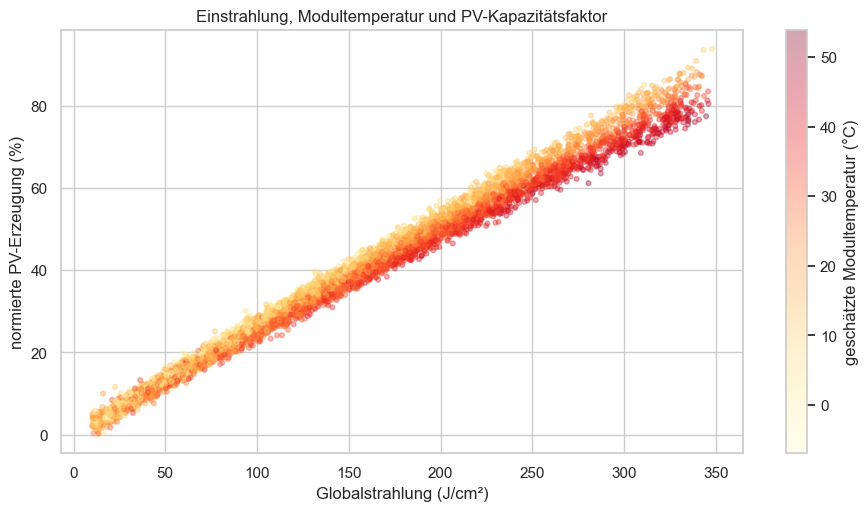

In [4]:
daylight = hourly[
    (hourly["global_radiation_j_cm2"] > 10) & hourly[TARGET].notna()
].copy()
sample = daylight.sample(min(6000, len(daylight)), random_state=42)

plt.figure(figsize=(11, 5.5))
scatter = plt.scatter(
    sample["global_radiation_j_cm2"],
    sample[TARGET] * 100,
    c=sample["estimated_module_temperature_c"],
    cmap="YlOrRd",
    s=12,
    alpha=.35,
)
plt.colorbar(scatter, label="geschätzte Modultemperatur (°C)")
plt.xlabel("Globalstrahlung (J/cm²)")
plt.ylabel("normierte PV-Erzeugung (%)")
plt.title("Einstrahlung, Modultemperatur und PV-Kapazitätsfaktor")
plt.show()

## 5. Test der Temperaturthese bei starker Einstrahlung

Um Einstrahlung grob zu kontrollieren, werden nur Stunden im oberen
Strahlungsquartil verglichen. Saison, Sonnenstand und Wetter bleiben dennoch
mögliche Störfaktoren.

,Stunden,Mittelwert,Median
temperature_class,,,
< 15 °C,1830,68.44,66.97
15–25 °C,1259,63.84,62.72
25–30 °C,98,60.40,59.09
≥ 30 °C,3,60.85,61.12


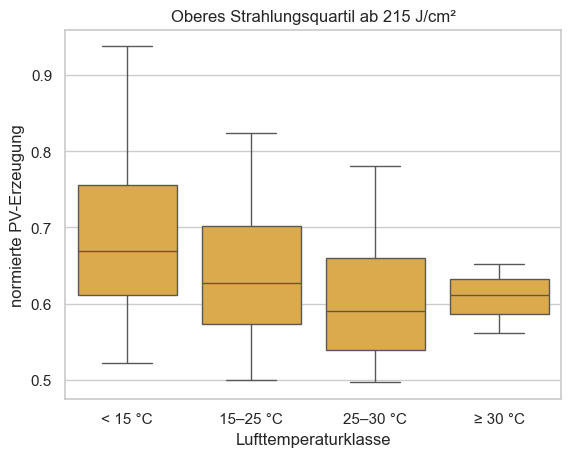

In [5]:
high_radiation_limit = daylight["global_radiation_j_cm2"].quantile(.75)
strong_sun = daylight[daylight["global_radiation_j_cm2"] >= high_radiation_limit].copy()
strong_sun["temperature_class"] = pd.cut(
    strong_sun["temperature_c"],
    [-30, 15, 25, 30, 60],
    labels=["< 15 °C", "15–25 °C", "25–30 °C", "≥ 30 °C"],
)
temperature_summary = strong_sun.groupby("temperature_class", observed=True)[TARGET].agg(
    Stunden="size", Mittelwert="mean", Median="median"
)
temperature_summary[["Mittelwert", "Median"]] *= 100
display(temperature_summary.round(2))

sns.boxplot(
    data=strong_sun.sample(min(8000, len(strong_sun)), random_state=42),
    x="temperature_class",
    y=TARGET,
    color="#F2B134",
    showfliers=False,
)
plt.xlabel("Lufttemperaturklasse")
plt.ylabel("normierte PV-Erzeugung")
plt.title(f"Oberes Strahlungsquartil ab {high_radiation_limit:.0f} J/cm²")
plt.show()

## 6. Wetterbedingungen der besten Stunden

Die Top-2%-Stunden beschreiben ein beobachtungsnahes Optimum. Sie sind kein
technisch garantiertes Anlagenoptimum und hängen von Messnetz, Zeitraum und
räumlicher Aggregation ab.

In [6]:
top = hourly.nlargest(max(50, int(len(hourly) * .02)), TARGET)
optimum = top[
    [
        TARGET, "global_radiation_j_cm2", "diffuse_radiation_j_cm2",
        "temperature_c", "estimated_module_temperature_c",
        "cloud_cover_oktas", "wind_speed_m_s", "relative_humidity_pct",
        "hour", "month",
    ]
].median().to_frame("Median Top 2 %")
display(optimum.round(2))

,Median Top 2 %
normalized_pv_generation,0.80
global_radiation_j_cm2,321.50
diffuse_radiation_j_cm2,46.79
temperature_c,5.44
estimated_module_temperature_c,25.09
cloud_cover_oktas,0.00
wind_speed_m_s,3.54
relative_humidity_pct,69.64
hour,12.00
month,5.00


## 7. Zeitlich ehrliches Prognosemodell

Die ersten 80 % der vollständigen Beobachtungen bilden das Training, die
neuesten 20 % einen zusammenhängenden Test. Das verhindert zufälliges
Vermischen von Vergangenheit und Zukunft.

In [7]:
bundle = train_yield_model(data)
metrics = pd.DataFrame(
    {
        "Gradient Boosting": [
            bundle.metrics["model_mae"] * 100,
            bundle.metrics["model_rmse"] * 100,
            bundle.metrics["model_r2"],
        ],
        "Median-Baseline": [
            bundle.metrics["baseline_mae"] * 100,
            bundle.metrics["baseline_rmse"] * 100,
            bundle.metrics["baseline_r2"],
        ],
    },
    index=["MAE (Prozentpunkte)", "RMSE (Prozentpunkte)", "R²"],
)
print(f"Zeitlicher Test beginnt: {bundle.split_timestamp}")
display(metrics.round(3))

Zeitlicher Test beginnt: 2024-05-26 19:00:00+00:00


,Gradient Boosting,Median-Baseline
MAE (Prozentpunkte),0.610,21.822
RMSE (Prozentpunkte),0.977,32.598
R²,0.998,-0.812


## 8. Wichtigste Einflussmerkmale

Permutation Importance misst den Anstieg des Testfehlers beim zufälligen
Vertauschen eines Merkmals. Korrelierte Wettergrößen teilen sich Bedeutung;
die Werte sind keine kausalen Effekte.

,Permutation Importance
Globalstrahlung,0.247881
sunshine_duration_min,0.002025
geschätzte Modultemperatur,0.001332
Lufttemperatur,0.001143
diffuse_radiation_j_cm2,0.000587
Sonnenzenit,0.000449
Wind,0.000157
Strahlung × thermischer Stress,0.000046
hour_cos,0.000032
Bewölkung,0.000004


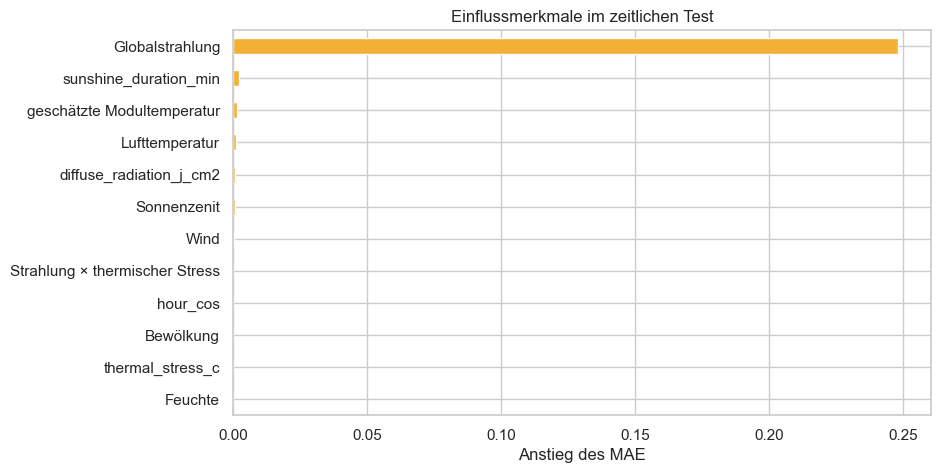

In [8]:
labels = {
    "global_radiation_j_cm2": "Globalstrahlung",
    "solar_zenith_angle_deg": "Sonnenzenit",
    "estimated_module_temperature_c": "geschätzte Modultemperatur",
    "temperature_c": "Lufttemperatur",
    "cloud_cover_oktas": "Bewölkung",
    "wind_speed_m_s": "Wind",
    "relative_humidity_pct": "Feuchte",
    "radiation_thermal_interaction": "Strahlung × thermischer Stress",
}
importance = (
    pd.Series(bundle.feature_importance)
    .sort_values(ascending=False)
    .head(12)
    .rename(index=labels)
)
display(importance.to_frame("Permutation Importance"))
importance.sort_values().plot.barh(figsize=(9, 5), color="#F2B134")
plt.xlabel("Anstieg des MAE")
plt.title("Einflussmerkmale im zeitlichen Test")
plt.show()

## 9. Szenario und thermischer Vergleich

Zwei Szenarien unterscheiden sich nur in der Lufttemperatur. Das Modell nutzt
ansonsten identische Wetter- und Kalenderwerte.

In [9]:
def scenario(temperature):
    radiation = 280.0
    wind = 3.0
    return pd.DataFrame({
        "timestamp_utc": [pd.Timestamp("2024-07-01 11:00", tz="UTC")],
        "temperature_c": [temperature],
        "relative_humidity_pct": [50.0],
        "global_radiation_j_cm2": [radiation],
        "diffuse_radiation_j_cm2": [radiation * .25],
        "sunshine_duration_min": [50.0],
        "solar_zenith_angle_deg": [30.0],
        "cloud_cover_oktas": [1.5],
        "wind_speed_m_s": [wind],
    })

comparison = pd.concat(
    [
        predict_yield(bundle, scenario(22)).assign(Szenario="22 °C Luft"),
        predict_yield(bundle, scenario(36)).assign(Szenario="36 °C Luft"),
    ],
    ignore_index=True,
)
comparison["Prognose (%)"] = comparison["normalized_pv_prediction"] * 100
display(comparison[["Szenario", "Prognose (%)", "lower_80", "upper_80"]])

,Szenario,Prognose (%),lower_80,upper_80
0,22 °C Luft,66.639048,0.653732,0.678316
1,36 °C Luft,64.976979,0.637112,0.661695


## 10. Fazit und Grenzen

Die Forschungsfrage wird über den Zusammenhang zwischen Einstrahlung,
geschätzter Modultemperatur und normierter PV-Erzeugung beantwortet. Eine
empirische Schlussfolgerung ist nur zulässig, wenn oben Realdaten ausgewiesen
sind.

Wichtige Grenzen:

- Stationsmittel approximieren das Wetter der räumlich verteilten PV-Flotte.
- Regionale PV-Gewichte sind stärker als reine Stationsmittel.
- Jährliche Kapazitätswerte bilden unterjährigen Ausbau nicht ab.
- Lufttemperatur ist nicht Modultemperatur; letztere wird nur angenähert.
- Anlagenneigung, Ausrichtung, Schnee, Verschattung, Abregelung und technische
  Verfügbarkeit fehlen.
- Gruppenvergleiche und Feature Importance sind keine Kausalnachweise.